In [21]:
from pathlib import Path
from PIL import Image
from collections import Counter

import random
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [7]:
plt.style.use('default')

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
VAL_DIR = DATA_DIR / "validation"

TRAIN_DIR, TEST_DIR, VAL_DIR

(PosixPath('/Users/herrickliu/ML_Project_github/ML_e2e/data/train'),
 PosixPath('/Users/herrickliu/ML_Project_github/ML_e2e/data/test'),
 PosixPath('/Users/herrickliu/ML_Project_github/ML_e2e/data/validation'))

### Ready to check class distribution

Now that we have all the image paths, let’s check how many images each class contains.

In [10]:
def count_images_per_class(data_dir: Path) -> pd.DataFrame:
    """Count the number of images per class in the given data directory."""
    rows = []
    for class_dir in data_dir.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            image_count = len(list(class_dir.glob("*.jpg")))
            rows.append({"class_name": class_name, "image_count": image_count})
    return pd.DataFrame(rows)

train_class_counts = count_images_per_class(TRAIN_DIR)
val_class_counts = count_images_per_class(VAL_DIR)
test_class_counts = count_images_per_class(TEST_DIR)

train_class_counts, test_class_counts, val_class_counts

(   class_name  image_count
 0       skirt          112
 1  longsleeve          455
 2       dress          241
 3       pants          468
 4     t-shirt          795
 5      shorts          202
 6         hat          123
 7       shoes          198
 8       shirt          290
 9     outwear          184,
    class_name  image_count
 0       skirt           12
 1  longsleeve           72
 2       dress           15
 3       pants           42
 4     t-shirt           52
 5      shorts           30
 6         hat           12
 7       shoes           73
 8       shirt           26
 9     outwear           38,
    class_name  image_count
 0       skirt           12
 1  longsleeve           49
 2       dress           32
 3       pants           49
 4     t-shirt           81
 5      shorts           25
 6         hat           14
 7       shoes           26
 8       shirt           29
 9     outwear           24)

### Visualize class distribution

Let’s visualize the class distribution in the training set to check for any major class imbalances

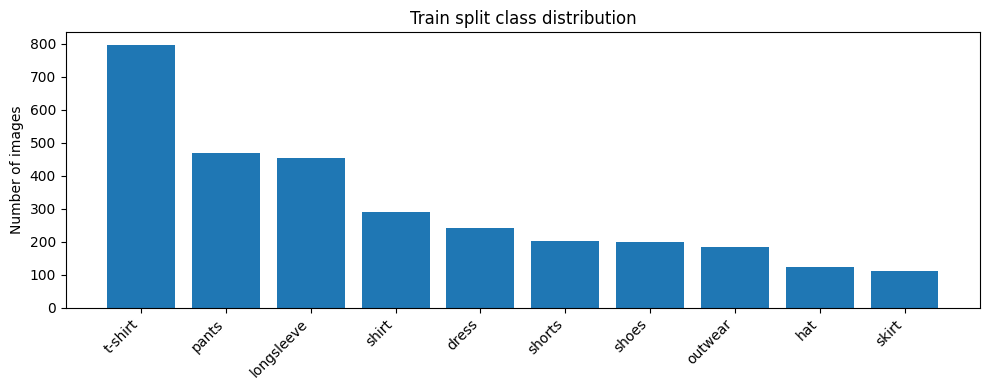

,class_name,image_count
4,t-shirt,795
3,pants,468
1,longsleeve,455
8,shirt,290
2,dress,241
5,shorts,202
7,shoes,198
9,outwear,184
6,hat,123
0,skirt,112


In [12]:
train_class_counts_sorted = train_class_counts.sort_values("image_count", ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(train_class_counts_sorted["class_name"], train_class_counts_sorted["image_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Train split class distribution")
plt.tight_layout()
plt.show()

train_class_counts_sorted


### 📝 **Findings: Class Distribution Analysis**

The training split shows a noticeable but manageable class imbalance. The most common class (t-shirt, 795 images) has roughly seven times more samples than the least common class (skirt, 112 images). However, all classes have more than 100 images, which is sufficient for training a reasonably robust model. The imbalance is therefore not extreme and should not prevent the model from learning meaningful representations for each category.

That said, this imbalance can still influence performance, especially for minority classes such as skirt and hat. To address this, we will keep class imbalance in mind during the model development process and monitor per-class performance during evaluation. If needed, we may introduce techniques such as class weighting to improve performance on underrepresented classes.

### Display images

Now, let’s take a look at the images themselves.

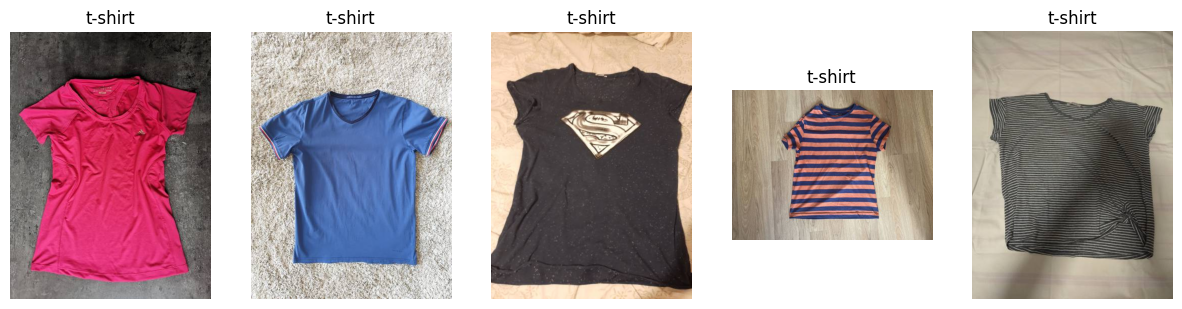

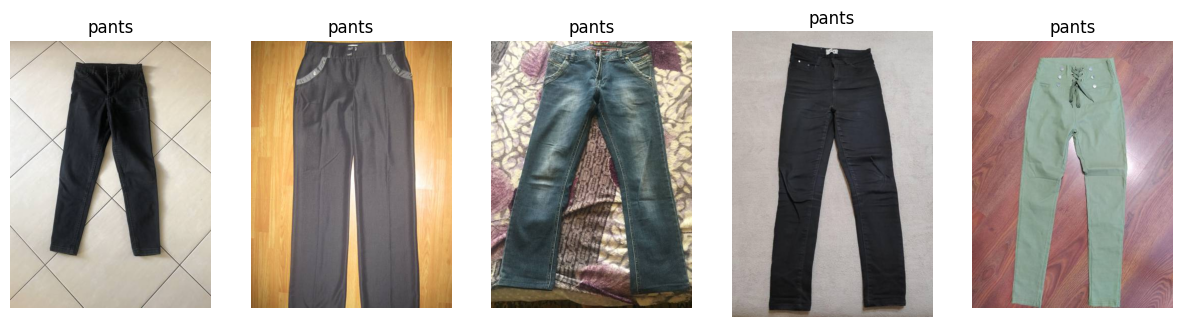

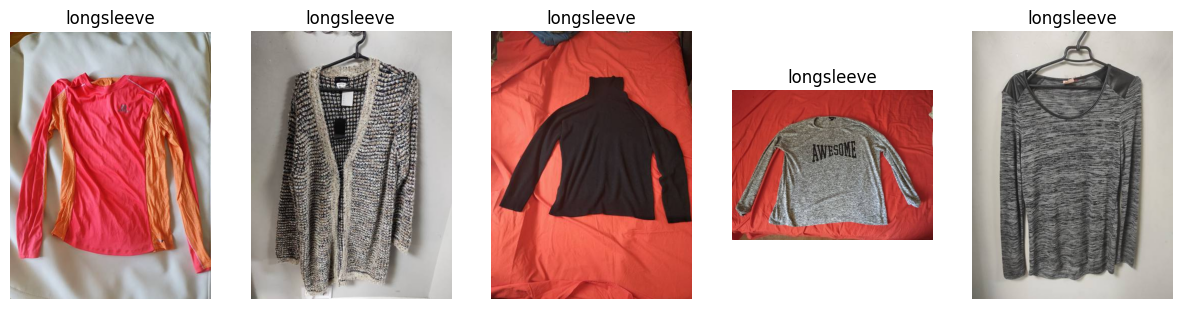

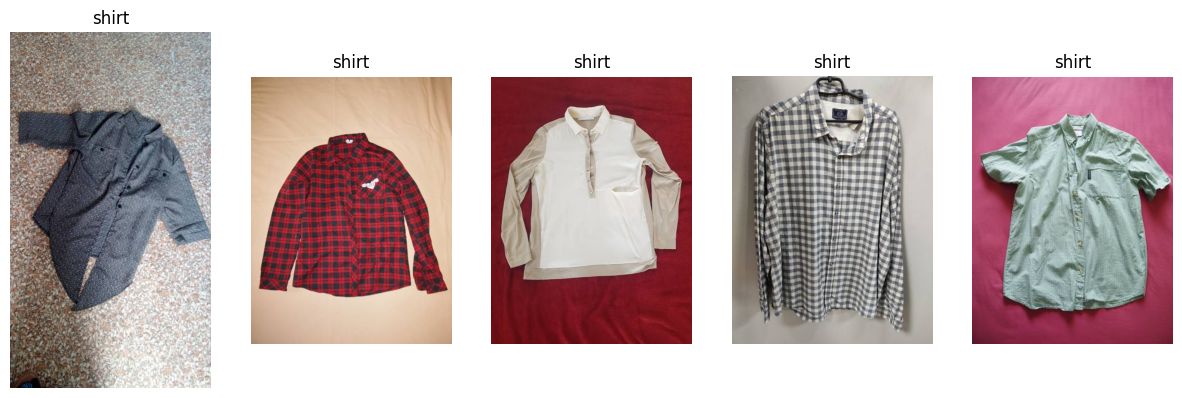

In [13]:
def show_random_images(data_dir: Path, class_name: str, num_images: int = 5) -> None:
    """Display random images from a specified class in the given data directory."""
    class_dir = data_dir / class_name
    image_paths = list(class_dir.glob("*.jpg"))
    selected_images = random.sample(image_paths, min(num_images, len(image_paths)))
    
    plt.figure(figsize=(15, 5))
    for i, image_path in enumerate(selected_images):
        img = Image.open(image_path)
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{class_name}")
    plt.show()

example_class = list(train_class_counts_sorted["class_name"])[:4]
for class_name in example_class:
    show_random_images(TRAIN_DIR, class_name, num_images=5)

### Analyze image size

Notice that the images come in different sizes. Let’s examine the overall distribution of image widths and heights, which will help us determine a suitable target size for resizing.

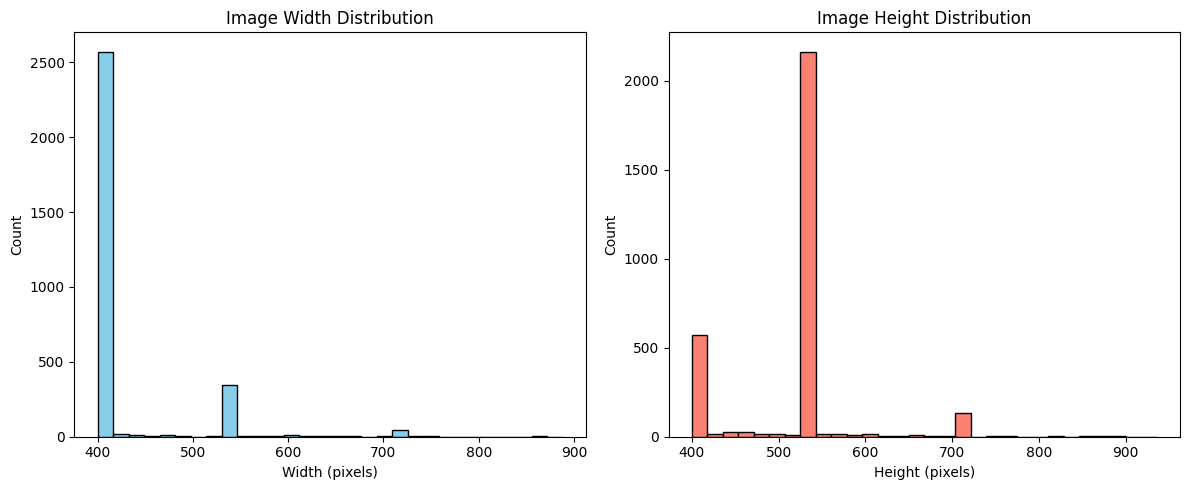

Width stats:
  min: 400
  max: 888
  mean: 425.4941329856584
  median: 400.0

Height stats:
  min: 400
  max: 936
  mean: 517.1310299869622
  median: 533.0


,"(width, height)",count
0,"(400, 533)",1632
1,"(400, 534)",491
2,"(533, 400)",226
3,"(534, 400)",112
4,"(400, 711)",104
5,"(711, 400)",44
6,"(400, 400)",41
7,"(400, 532)",25
8,"(400, 712)",18
9,"(400, 537)",8


In [23]:
def get_image_sizes(data_dir: Path) -> pd.DataFrame:
    """Get the dimensions of all images in the given data directory."""
    widths = []
    heights = []
    for class_dir in data_dir.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            for image_path in class_dir.glob("*.jpg"):
                with Image.open(image_path) as img:
                    width, height = img.size
                    widths.append(width)
                    heights.append(height)
    return widths, heights

widths, heights = get_image_sizes(TRAIN_DIR)

len(widths), len(heights)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=30, color='skyblue', edgecolor='black')
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.hist(heights, bins=30, color='salmon', edgecolor='black')
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("Width stats:")
print("  min:", np.min(widths))
print("  max:", np.max(widths))
print("  mean:", np.mean(widths))
print("  median:", np.median(widths))

print("\nHeight stats:")
print("  min:", np.min(heights))
print("  max:", np.max(heights))
print("  mean:", np.mean(heights))
print("  median:", np.median(heights))

size_counts = Counter(zip(widths, heights))

# Show the top 10 most common resolutions
pd.DataFrame(size_counts.most_common(10), columns=["(width, height)", "count"])

### 📝 Findings: Image Size Distribution

The image resolution distribution shows that most images fall into a small set of very common sizes, such as around 400 px in width and roughly 530 px in height. Although there are some larger images, they appear infrequently, and there are no extremely small or unusable images. Overall, the dataset is reasonably consistent, even if the aspect ratios differ across classes.

---

### Resizing Strategy

Since image sizes are not uniform, all images must be resized to a consistent resolution before training a CNN. Given that the original images cluster around similar moderate sizes and that standard CNN architectures expect square inputs, a target resolution of: **224 × 224** is appropriate. This size is widely used in TensorFlow models, efficient to train, and sufficient to capture the visual details needed for clothing classification. Any minor stretching or compression introduced by resizing is acceptable and will be further mitigated by data augmentation during training.

### Tring out pre-process with tensorflow

Now we have fully understand our data, we could build a simple pre processing pipeline using tensorflow

In the following code blocks, we will load the data using tensorflow, perform image resize, normalization/rescale and data augmentation

In [25]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets and resize images
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print("Class names:", class_names)

# Normalization layer
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255.0)

# Data augmentation layer for training dataset
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

def prepare_train_dataset(ds):
    ds = ds.map(
        lambda x, y: (data_augmentation(normalization_layer(x)), y),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.cache().prefetch(AUTOTUNE)
    return ds


def prepare_test_eval_dataset(ds):
    ds = ds.map(
        lambda x, y: (normalization_layer(x), y),
        num_parallel_calls=AUTOTUNE,
    )
    ds = ds.cache().prefetch(AUTOTUNE)
    return ds


train_ds = prepare_train_dataset(train_ds_raw)
test_ds = prepare_test_eval_dataset(test_ds_raw)
val_ds = prepare_test_eval_dataset(val_ds_raw)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Pixel range:", float(tf.reduce_min(images)), "→", float(tf.reduce_max(images)))


Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.
Found 341 files belonging to 10 classes.
Class names: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 → 1.0


2025-11-17 00:35:37.613182: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-11-17 00:35:38.102007: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
